In [2]:
import numpy as np 
import pandas as pd 
from sklearn.datasets import load_iris

In [3]:
#load dataset
iris = load_iris()

In [4]:
#Features and target
X = iris.data
y = iris.target

In [6]:
#Convert to Dataframe 
df = pd.DataFrame(X, columns=iris.feature_names)
df['target'] = y
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [8]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


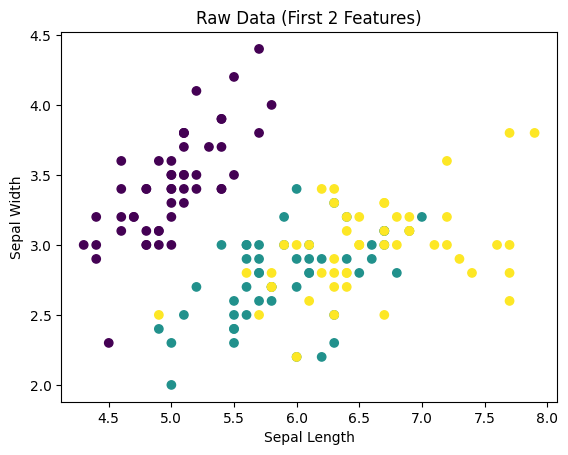

In [10]:
import matplotlib.pyplot as plt
plt.scatter(X[:,0],X[:,1],c=y)
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("Raw Data (First 2 Features)")
plt.show()

In [11]:
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Fit and transform
X_scaled = scaler.fit_transform(X)

# Check result
print("Mean (approx 0):", np.mean(X_scaled, axis=0))
print("Std (approx 1):", np.std(X_scaled, axis=0))

Mean (approx 0): [-1.69031455e-15 -1.84297022e-15 -1.69864123e-15 -1.40924309e-15]
Std (approx 1): [1. 1. 1. 1.]


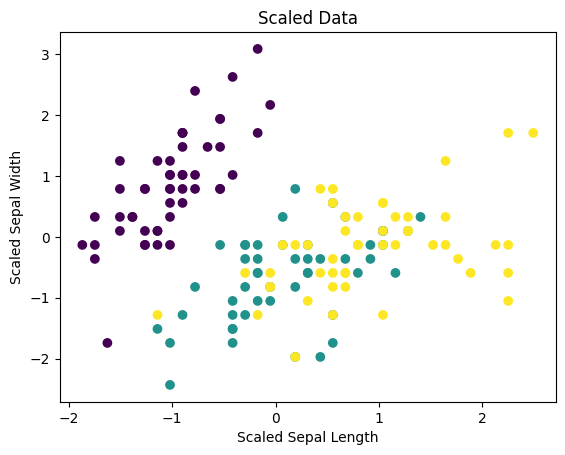

In [12]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y)
plt.xlabel("Scaled Sepal Length")
plt.ylabel("Scaled Sepal Width")
plt.title("Scaled Data")
plt.show()


In [13]:
from sklearn.decomposition import PCA

# Initialize PCA (reduce to 2 dimensions)
pca = PCA(n_components=2)

# Apply PCA
X_pca = pca.fit_transform(X_scaled)

# Shape check
print("Original shape:", X_scaled.shape)
print("Reduced shape:", X_pca.shape)

Original shape: (150, 4)
Reduced shape: (150, 2)


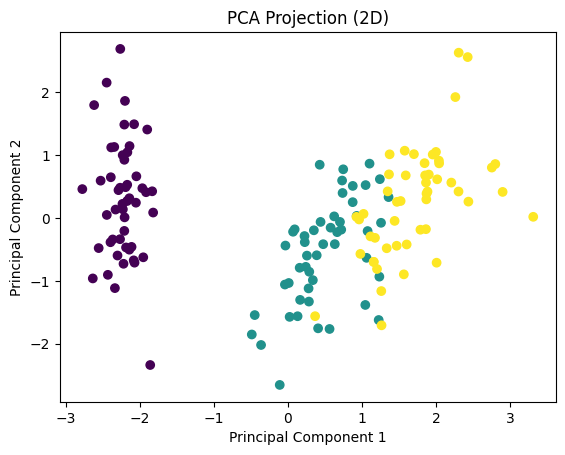

In [14]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection (2D)")
plt.show()


In [15]:
print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Total Variance Captured:", np.sum(pca.explained_variance_ratio_))

Explained Variance Ratio: [0.72962445 0.22850762]
Total Variance Captured: 0.9581320720000166


Meaning:

PC1 → 72% information
PC2 → 23%
Total → 95%
We kept 95% information using only 2 features

In [ ]:
# Each row = one principal component
components = pca.components_

# Convert to DataFrame for clarity
comp_df = pd.DataFrame(components, columns=iris.feature_names)

comp_df

# Large value → feature is important
# Small value → less important

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,0.521066,-0.269347,0.580413,0.564857
1,0.377418,0.923296,0.024492,0.066942


In [17]:
# Absolute importance
importance = np.abs(pca.components_)

pd.DataFrame(importance, columns=iris.feature_names)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,0.521066,0.269347,0.580413,0.564857
1,0.377418,0.923296,0.024492,0.066942


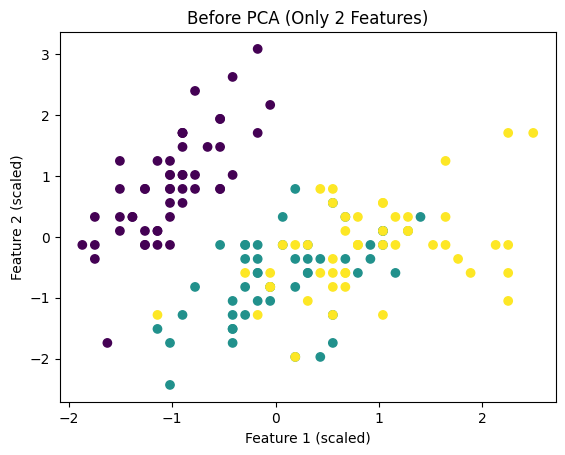

In [18]:
#Before PCA
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y)
plt.xlabel("Feature 1 (scaled)")
plt.ylabel("Feature 2 (scaled)")
plt.title("Before PCA (Only 2 Features)")
plt.show()

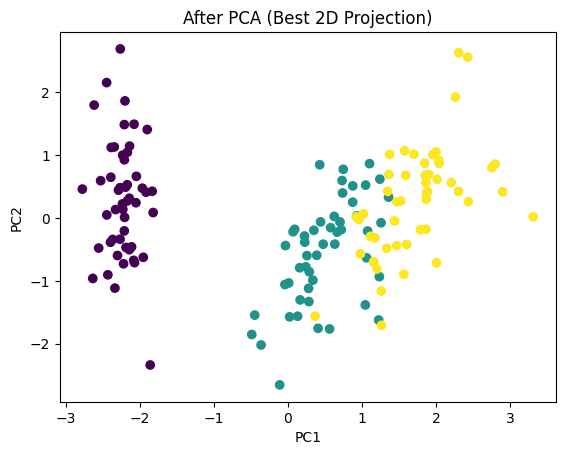

In [19]:
#After PCA
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("After PCA (Best 2D Projection)")
plt.show()

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Train on original data
model1 = LogisticRegression()
model1.fit(X_train, y_train)
pred1 = model1.predict(X_test)

# Train on PCA data
X_train_pca, X_test_pca, _, _ = train_test_split(X_pca, y, test_size=0.2, random_state=42)

model2 = LogisticRegression()
model2.fit(X_train_pca, y_train)
pred2 = model2.predict(X_test_pca)

print("Accuracy without PCA:", accuracy_score(y_test, pred1))
print("Accuracy with PCA:", accuracy_score(y_test, pred2))

Accuracy without PCA: 1.0
Accuracy with PCA: 0.9


Although PCA retained ~95% variance, model accuracy dropped from 1.0 to 0.9.
This shows that PCA does not guarantee better classification performance,
as it ignores class labels and may discard useful discriminative information.